Shape: (2190, 11)
Columns: ['id', 'recorded_day', 'air_pressure', 'max_temp', 'temperature', 'min_temp', 'dew_point', 'humidity', 'cloud_cover', 'wind_speed', 'raining']

Numerical features to plot: ['air_pressure', 'max_temp', 'temperature', 'min_temp', 'dew_point', 'humidity', 'cloud_cover', 'wind_speed']


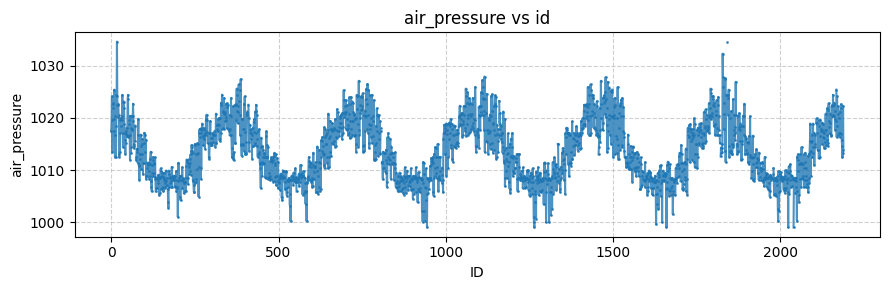

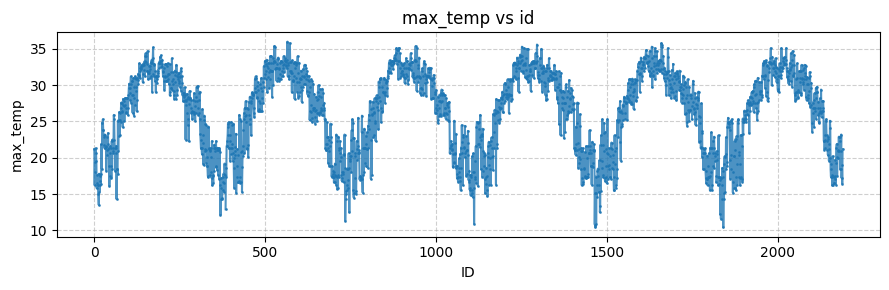

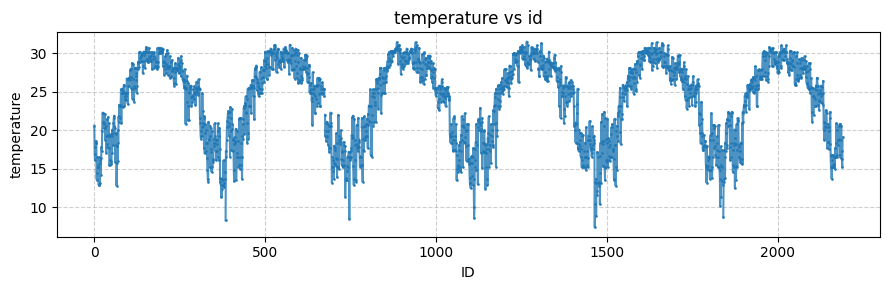

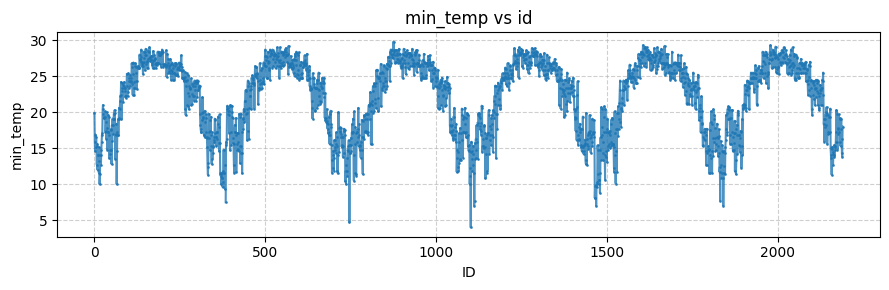

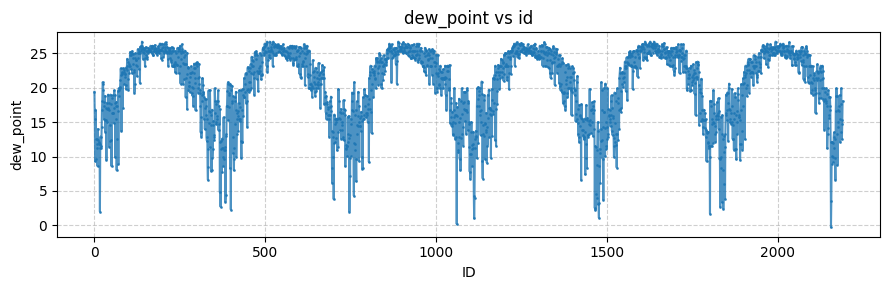

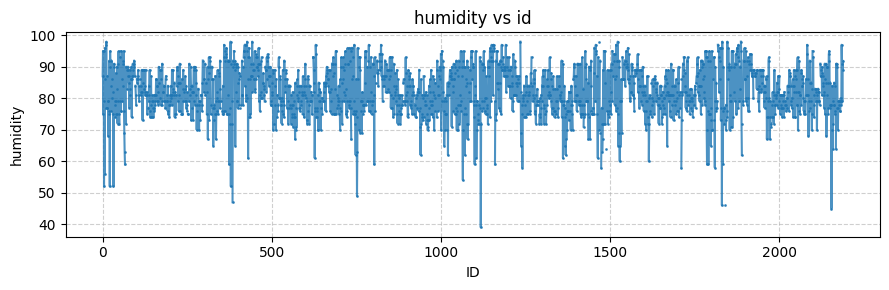

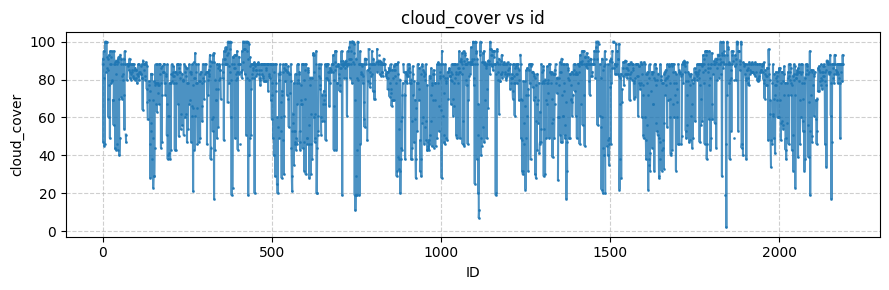

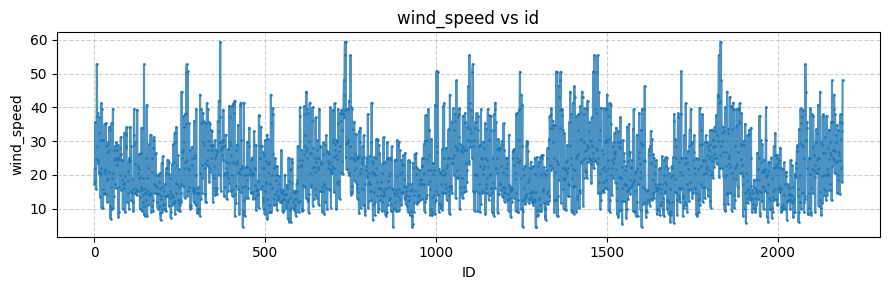

In [1]:
# ============================================================
# PART 1 (a): Plotting numerical features vs ID
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("rainfall_data.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Identify numeric columns (exclude recorded_day and ID)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'id' in num_cols:
    num_cols.remove('id')
elif 'ID' in num_cols:
    num_cols.remove('ID')

if 'recorded_day' in num_cols:
    num_cols.remove('recorded_day')

print("\nNumerical features to plot:", num_cols)

# Set the ID column (lower/upper case both handled)
id_col = 'id' if 'id' in df.columns else 'ID' if 'ID' in df.columns else None

# Loop and plot each feature vs ID
for col in num_cols:
    plt.figure(figsize=(9, 3))
    x = df[id_col] if id_col else df.index
    plt.plot(x, df[col], marker='.', linestyle='-', markersize=2, alpha=0.8)
    plt.title(f"{col} vs {id_col if id_col else 'Index'}")
    plt.xlabel("ID" if id_col else "Index")
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [ ]:
Prompt : Give me python code for the plots of columns except recorded day vs ID

In [ ]:
Prompt : Give me code to fill the missing values using moving averages taking the average of nearest values

In [13]:
# ============================================================
# Fill Missing Values using Simple Moving Average (Centered)
# ============================================================

import pandas as pd

# Load dataset
df = pd.read_csv("rainfall_data.csv")

# Identify numeric columns (exclude id and recorded_day)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')
if 'recorded_day' in num_cols: num_cols.remove('recorded_day')

# Set window size
window = 5

# Fill missing values directly in the original dataframe
for col in num_cols:
    df[col] = df[col].fillna(
        df[col].rolling(window=window, center=True, min_periods=1).mean()
    )

# Check remaining missing values
print("Remaining missing values after moving average imputation:\n")
print(df[num_cols].isna().sum())
# Save the cleaned dataset for later steps
df.to_csv("rainfall_data_filled.csv", index=False)
print("\n✅ Cleaned dataset saved as 'rainfall_data_filled.csv'")



Remaining missing values after moving average imputation:

air_pressure    0
max_temp        0
temperature     0
min_temp        0
dew_point       0
humidity        0
cloud_cover     0
wind_speed      0
dtype: int64

✅ Cleaned dataset saved as 'rainfall_data_filled.csv'


In [ ]:
prompt : Implement PCA and t-SNE on the datasets

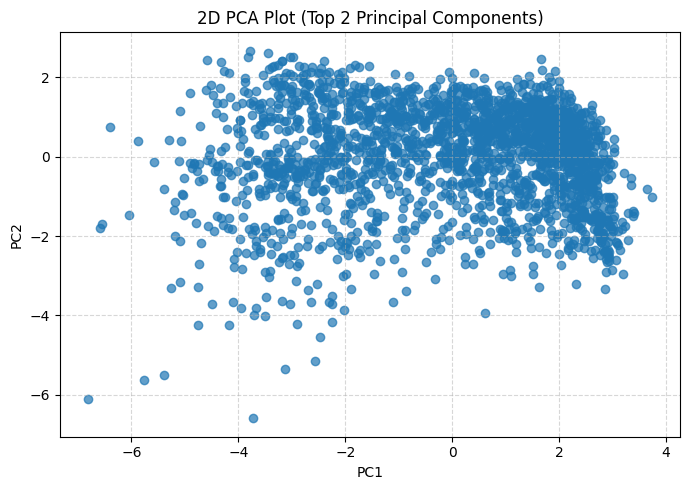

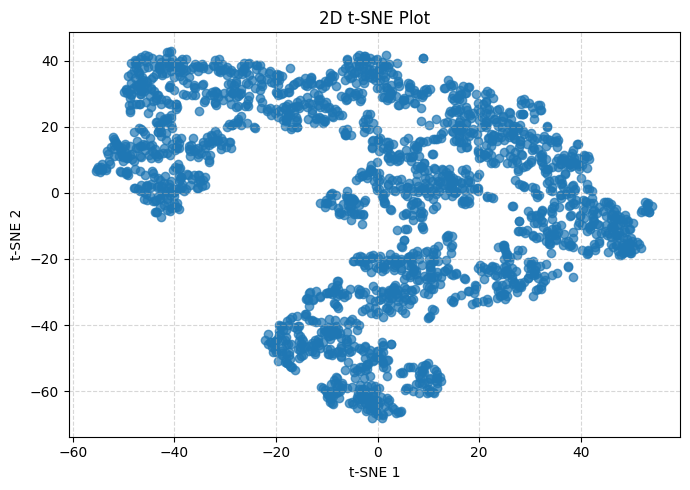

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ================= Prepare Data =================
# Include all numeric features including recorded_day
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')  # remove only ID

X = df[num_cols].values

# ================= Standardize Features =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= 2D PCA =================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Plot (Top 2 Principal Components)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ================= 2D t-SNE =================
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("2D t-SNE Plot")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
Prompt : Implement logistic regression and 5-fold cross validation on the dataset. Calculate ROC-AUC for each fold and the average ROC-AUC score.

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ================= Prepare Data =================
# Features: all numeric columns including recorded_day, exclude only 'id'
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')  # remove only ID

X = df[num_cols].values

# Target: last column in the CSV (yes/no)
target_col = df.columns[-1]
y = df[target_col].values

# Encode yes/no to 1/0
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'no'->0, 'yes'->1

# ================= Scale Features =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= Logistic Regression =================
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_scores = cross_val_score(logreg, X_scaled, y_encoded, cv=cv, scoring='roc_auc')

# ================= Results =================
print("ROC-AUC scores for each fold:", roc_auc_scores)
print("Average ROC-AUC score:", np.mean(roc_auc_scores))


ROC-AUC scores for each fold: [0.9127385  0.85516274 0.87317621 0.89713805 0.87497194]
Average ROC-AUC score: 0.8826374859708193


In [ ]:
Prompt : Give me code to calculate the VIF of all the features and ROC-AUC after removing 3,6 and 8 columns

VIF values for all columns:

        Feature        VIF
3   temperature  80.533148
4      min_temp  44.534333
2      max_temp  32.168273
5     dew_point  11.500489
1  air_pressure   3.481904
6      humidity   1.826524
7   cloud_cover   1.765811
8    wind_speed   1.166219
0  recorded_day   1.097079
Drop 3 columns - Average ROC-AUC: 0.8808
Drop 6 columns - Average ROC-AUC: 0.8633
Drop 8 columns - Average ROC-AUC: 0.4799


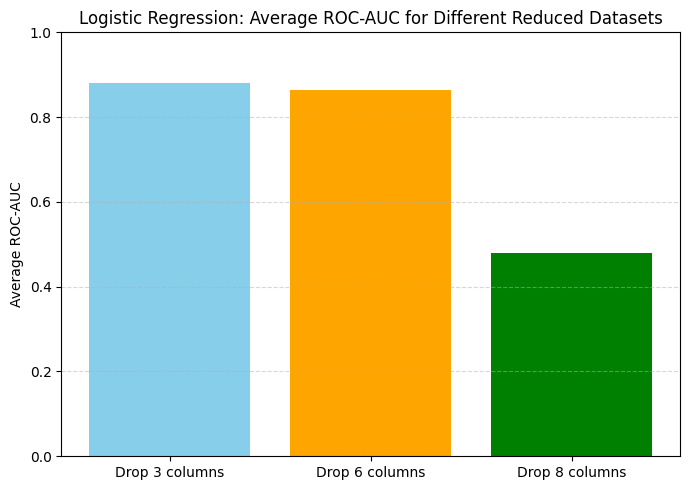

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# ================= Prepare Data =================
# Include all numeric features except 'id'
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')

X = df[num_cols].copy()

# Target: last column (yes/no)
target_col = df.columns[-1]
y = df[target_col].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'no'->0, 'yes'->1

# ================= Standardize Features =================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=num_cols)

# ================= Compute VIF =================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("VIF values for all columns:\n")
print(vif_data)

# ================= Drop columns based on VIF =================
drop_3 = vif_data['Feature'].iloc[:3].tolist()
drop_6 = vif_data['Feature'].iloc[:6].tolist()
drop_8 = vif_data['Feature'].iloc[:8].tolist()

X_drop3 = X_scaled.drop(columns=drop_3)
X_drop6 = X_scaled.drop(columns=drop_6)
X_drop8 = X_scaled.drop(columns=drop_8)

# ================= Logistic Regression + 5-Fold CV =================
logreg = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

datasets = {'Drop 3 columns': X_drop3, 'Drop 6 columns': X_drop6, 'Drop 8 columns': X_drop8}
roc_auc_scores_avg = []

for name, X_data in datasets.items():
    scores = cross_val_score(logreg, X_data.values, y_encoded, cv=cv, scoring='roc_auc')
    roc_auc_scores_avg.append(np.mean(scores))
    print(f"{name} - Average ROC-AUC: {np.mean(scores):.4f}")

# ================= Plot Average ROC-AUC =================
plt.figure(figsize=(7,5))
plt.bar(datasets.keys(), roc_auc_scores_avg, color=['skyblue', 'orange', 'green'])
plt.ylabel("Average ROC-AUC")
plt.title("Logistic Regression: Average ROC-AUC for Different Reduced Datasets")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
roc_auc_vif = roc_auc_scores_avg.copy()

In [ ]:
Prompt : Give me code to calculate ROC-AUC for 1,3 and 6 PCAs.

Top 1 PC(s) explain 0.5333 of variance.
Top 3 PC(s) explain 0.8299 of variance.
Top 6 PC(s) explain 0.9879 of variance.
1 PC(s) - Average ROC-AUC: 0.5594
3 PC(s) - Average ROC-AUC: 0.8741
6 PC(s) - Average ROC-AUC: 0.8816


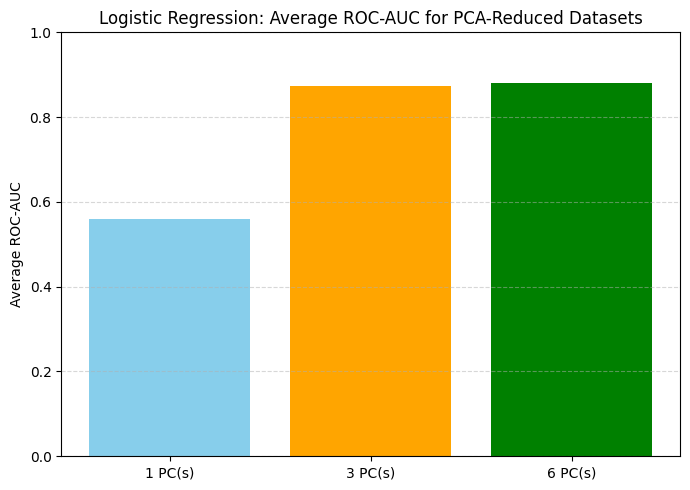

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# ================= Prepare Data =================
# Include all numeric features except 'id'
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')

X = df[num_cols].copy()

# Target: last column (yes/no)
target_col = df.columns[-1]
y = df[target_col].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'no'->0, 'yes'->1

# ================= Standardize Features =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= PCA =================
pca_components = [1, 3, 6]
X_pca_datasets = {}

for n in pca_components:
    pca = PCA(n_components=n, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_datasets[f"{n} PC(s)"] = X_pca
    explained_var = np.sum(pca.explained_variance_ratio_)
    print(f"Top {n} PC(s) explain {explained_var:.4f} of variance.")

# ================= Logistic Regression + 5-Fold CV =================
logreg = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores_avg = []

for name, X_data in X_pca_datasets.items():
    scores = cross_val_score(logreg, X_data, y_encoded, cv=cv, scoring='roc_auc')
    roc_auc_scores_avg.append(np.mean(scores))
    print(f"{name} - Average ROC-AUC: {np.mean(scores):.4f}")

# ================= Plot Average ROC-AUC =================
plt.figure(figsize=(7,5))
plt.bar(X_pca_datasets.keys(), roc_auc_scores_avg, color=['skyblue', 'orange', 'green'])
plt.ylabel("Average ROC-AUC")
plt.title("Logistic Regression: Average ROC-AUC for PCA-Reduced Datasets")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
roc_auc_pca = roc_auc_scores_avg.copy()

In [ ]:
Prompt : Make a table comparing all teh ROC-AUC scores of VIF and PCA

In [9]:
import pandas as pd



# ================= Create Comparison Table =================
comparison_df = pd.DataFrame({
    "Approach": ["VIF - Drop 3", "VIF - Drop 6", "VIF - Drop 8",
                 "PCA - 1 PC", "PCA - 3 PCs", "PCA - 6 PCs"],
    "Average ROC-AUC": roc_auc_vif + roc_auc_pca
})

print("\n===== Comparison of Average ROC-AUC Scores =====\n")
print(comparison_df)



===== Comparison of Average ROC-AUC Scores =====

       Approach  Average ROC-AUC
0  VIF - Drop 3         0.880842
1  VIF - Drop 6         0.863333
2  VIF - Drop 8         0.479857
3    PCA - 1 PC         0.559405
4   PCA - 3 PCs         0.874052
5   PCA - 6 PCs         0.881627


In [ ]:
Prompt : Implement assigning weights, perform logistic regression and give me the average ROC-AUC

In [14]:
# ============================================================
# Logistic Regression with Class Weight Balancing
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load dataset (after filling missing values)
df = pd.read_csv("rainfall_data_filled.csv")

# Identify numeric columns (exclude id)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')

# Features and target
X = df[num_cols].copy()
target_col = df.columns[-1]   # assuming last column is 'raining' (yes/no)
y = df[target_col].values

# Encode target to binary
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression with class_weight
logreg_bal = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_scores_bal = cross_val_score(logreg_bal, X_scaled, y_encoded, cv=cv, scoring='roc_auc')

# Results
print("===== Logistic Regression (Class Weight Balanced) =====")
print("ROC–AUC scores for each fold:", np.round(roc_auc_scores_bal, 4))
print("Average ROC–AUC score:", np.mean(roc_auc_scores_bal).round(4))


===== Logistic Regression (Class Weight Balanced) =====
ROC–AUC scores for each fold: [0.9114 0.8545 0.872  0.8982 0.875 ]
Average ROC–AUC score: 0.8822


In [ ]:
Prompt : Implement SMOTE and calculate ROC-AUC score

In [15]:
# ============================================================
# Logistic Regression with SMOTE (Oversampling)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Load dataset (after filling missing values)
df = pd.read_csv("rainfall_data_filled.csv")

# Identify numeric columns (exclude id)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')

# Features and target
X = df[num_cols].copy()
target_col = df.columns[-1]
y = df[target_col].values

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Define 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: SMOTE -> StandardScaler -> Logistic Regression
smote = SMOTE(random_state=42)
scaler = StandardScaler()
logreg_smote = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('scaler', scaler),
    ('clf', logreg_smote)
])

# ROC–AUC with 5-fold CV
roc_auc_scores_smote = cross_val_score(pipeline, X, y_encoded, cv=cv, scoring='roc_auc')

# Results
print("\n===== Logistic Regression (SMOTE Oversampling) =====")
print("ROC–AUC scores for each fold:", np.round(roc_auc_scores_smote, 4))
print("Average ROC–AUC score:", np.mean(roc_auc_scores_smote).round(4))



===== Logistic Regression (SMOTE Oversampling) =====
ROC–AUC scores for each fold: [0.9091 0.8527 0.8749 0.897  0.8749]
Average ROC–AUC score: 0.8817


In [ ]:
Prompt : Generate a plot of ROC-AUC during class imbalance, SMOTE and Class weights

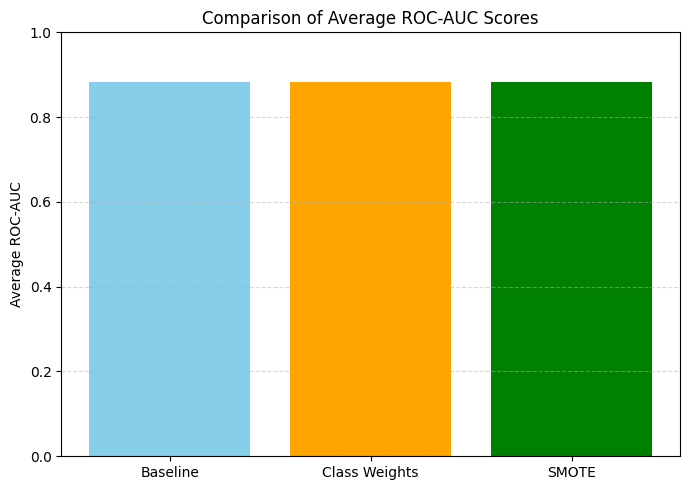

In [16]:
import matplotlib.pyplot as plt

# Suppose these are your average ROC-AUC scores
avg_roc_scores = [np.mean(roc_auc_scores), np.mean(roc_auc_scores_bal).round(4), np.mean(roc_auc_scores_smote).round(4)]
methods = ['Baseline', 'Class Weights', 'SMOTE']

plt.figure(figsize=(7,5))
plt.bar(methods, avg_roc_scores, color=['skyblue', 'orange', 'green'])
plt.ylabel("Average ROC-AUC")
plt.title("Comparison of Average ROC-AUC Scores")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
